# Import Libraries & Data Cleaning

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import unicodedata
df = pd.read_csv("US-National-Parks_Use_1979-2023_By-Month.csv")
loc_df = pd.read_csv("df_2.csv")
# df.head()
#loc_df.head()

## Data cleaning (park names, distances, etc.)

In [21]:
#Clean park names for matching
def clean_park_name(name):
    # normalize unicode characters (fixes Haleakalā, Hawaiʻi, etc.)
    name = unicodedata.normalize('NFKD', name)
    name = name.encode('ascii', 'ignore').decode('utf-8')

    name = name.lower()
    
    # normalize punctuation
    name = name.replace('*', '')
    name = name.replace('–', '-')
    name = name.replace('.', '')
    
    # remove park designations
    name = re.sub(r'national park of', '', name)
    name = re.sub(r'national park', '', name)
    name = re.sub(r'np.*pres', '', name)
    name = re.sub(r'np', '', name)
    name = re.sub(r'preserve', '', name)
    
    # replace hyphens with spaces
    name = name.replace('-', ' ')
    
    # clean up whitespace
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name

In [22]:
df['clean_name'] = df['ParkName'].apply(clean_park_name) #apply cleaning function to ParkName column
loc_df['clean_name'] = loc_df['Name'].apply(clean_park_name) #apply cleaning function to Name column
df.loc[df['ParkName'].str.contains('Wrangell', na=False), 'clean_name'] = 'wrangell st elias' #manual fix for wrangell st elias
loc_df.loc[loc_df['Name'].str.contains('Wrangell', na=False), 'clean_name'] = 'wrangell st elias' #manual fix for wrangell st elias
unmatched = df[~df['clean_name'].isin(loc_df['clean_name'])] #find unmatched park names
unmatched[['ParkName', 'clean_name']] #display unmatched park names

,ParkName,clean_name


In [23]:
loc_df.head() #view location dataframe
loc_df = loc_df[['Name','Location','clean_name']] #keep only relevant columns
loc_df['Location'] # view Location column

0     Maine.mw-parser-output .geo-default,.mw-parser...
1     American Samoa14°15′S 170°41′W﻿ / ﻿14.25°S 170...
2             Utah38°41′N 109°34′W﻿ / ﻿38.68°N 109.57°W
3     South Dakota43°45′N 102°30′W﻿ / ﻿43.75°N 102.50°W
4            Texas29°15′N 103°15′W﻿ / ﻿29.25°N 103.25°W
                            ...                        
58    South Dakota43°34′N 103°29′W﻿ / ﻿43.57°N 103.48°W
59          Alaska61°00′N 142°00′W﻿ / ﻿61.00°N 142.00°W
60    Wyoming, Montana, Idaho44°36′N 110°30′W﻿ / ﻿44...
61      California37°50′N 119°30′W﻿ / ﻿37.83°N 119.50°W
62            Utah37°18′N 113°03′W﻿ / ﻿37.30°N 113.05°W
Name: Location, Length: 63, dtype: object

## Extract coordinates from the location cells in the dataset (so we can calculate distances between them)

In [24]:
def extract_decimal_coords(coord_str):
    """Extract decimal latitude and longitude from a string like:
    'Utah38°41′N 109°34′W﻿ / ﻿38.68°N 109.57°W'
    Returns (lat, lon) as floats.
    """
    if pd.isna(coord_str):
        return pd.Series([None, None])
    
    # Remove invisible characters like zero-width space
    coord_str = re.sub(r'[\u200B\uFEFF]', '', coord_str)
    
    # Regex to find the decimal portion after the slash
    match = re.search(r'/\s*([\d\.]+)°([NS])\s*([\d\.]+)°([EW])', coord_str)
    if match:
        lat = float(match.group(1))
        lon = float(match.group(3))
        
        # Adjust for hemisphere
        if match.group(2) == 'S':
            lat = -lat
        if match.group(4) == 'W':
            lon = -lon
        
        return pd.Series([lat, lon])
    
    return pd.Series([None, None])

# Example usage:
loc_df[['Latitude', 'Longitude']] = loc_df['Location'].apply(extract_decimal_coords)

In [25]:
new_df = df.merge(
    loc_df,
    on='clean_name',
    how='left',
)
# new_df

In [26]:
new_df = new_df.drop(columns=['Name'])

In [27]:
new_df = new_df.drop(columns=['Location'])

In [28]:
new_df['Region'].unique()
keep_cols = ['ParkName', 'clean_name', 'Region', 'Latitude', 'Longitude'] #For the purposes of this analysis, a park is uniquely identified by these things
total_visitation = (
    new_df.groupby(keep_cols, as_index=False)['RecreationVisits']
    .sum()
)
total_visitation

,ParkName,clean_name,Region,Latitude,Longitude,RecreationVisits
0,Acadia NP,acadia,Northeast,44.35,-68.21,134113188
1,Arches NP,arches,Intermountain,38.68,-109.57,39675085
2,Badlands NP,badlands,Midwest,43.75,-102.50,45958032
3,Big Bend NP,big bend,Intermountain,29.25,-103.25,14476096
4,Biscayne NP,biscayne,Southeast,25.65,-80.08,20815641
...,...,...,...,...,...,...
58,Wind Cave NP,wind cave,Midwest,43.57,-103.48,27639533
59,Wrangell-St. Elias NP & PRES,wrangell st elias,Alaska,61.00,-142.00,2039977
60,Yellowstone NP,yellowstone,Intermountain,44.60,-110.50,139394679
61,Yosemite NP,yosemite,Pacific West,37.83,-119.50,155709017


## Get the distances of each park within each region

In [29]:
regions = total_visitation['Region'].unique() #get unique regions
total_visitation['Region'] = total_visitation['Region'].str.strip() #strip whitespace from region names
parks_by_region = {region: df_region for region, df_region in total_visitation.groupby('Region')} #create dict of dataframes by region
regions

array(['Northeast ', 'Intermountain ', 'Midwest ', 'Southeast ',
       'Pacific West ', 'Alaska'], dtype=object)

In [30]:
# Haversine function
#checking distances between parks within the same region
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Load the total visitation dataset
parks = total_visitation

# Clean region column
parks['Region'] = parks['Region'].str.strip()

# Prepare results list
rows = []

# Loop through regions
for region, df_region in parks.groupby('Region'):
    df_region = df_region.reset_index(drop=True)
    for i, row1 in df_region.iterrows():
        for j, row2 in df_region.iterrows():
            dist = haversine(row1["Latitude"], row1["Longitude"], row2["Latitude"], row2["Longitude"])
            rows.append({
                "region": region,
                "from_park": row1["ParkName"],
                "to_park": row2["ParkName"],
                "distance_miles": dist
            })

# Convert to DataFrame
distances_df = pd.DataFrame(rows)

distances_df 

,region,from_park,to_park,distance_miles
0,Alaska,Denali NP & PRES,Denali NP & PRES,0.000000
1,Alaska,Denali NP & PRES,Gates of the Arctic NP & PRES,317.640328
2,Alaska,Denali NP & PRES,Glacier Bay NP & PRES,561.196044
3,Alaska,Denali NP & PRES,Katmai NP & PRES,366.145067
4,Alaska,Denali NP & PRES,Kenai Fjords NP,237.252793
...,...,...,...,...
848,Southeast,Virgin Islands NP,Dry Tortugas NP,1243.471531
849,Southeast,Virgin Islands NP,Everglades NP,1144.547108
850,Southeast,Virgin Islands NP,Great Smoky Mountains NP,1660.027026
851,Southeast,Virgin Islands NP,Mammoth Cave NP,1836.007240


We chose to use the Haversine function to calculate distances because it's able to calculate distances using latitude and longitude with accuracy. The Haversine formula determines the great-circle distance bewteen two points on a sphere, given the Lat/Long coordinates, which works perfectly with our goal of measuring the distance between national parks wihtin various regions based on their latitude & longitude.

In [31]:
# 1) remove self-distances for each park
dist_clean = distances_df[distances_df['from_park'] != distances_df['to_park']].copy()

# 2) create an unordered pair id so A-B and B-A become the same
dist_clean['pair'] = dist_clean.apply(
    lambda r: '||'.join(sorted([r['from_park'], r['to_park']])),
    axis=1
)

# 3) drop duplicate pairs within each region
dist_clean = dist_clean.drop_duplicates(subset=['region', 'pair'])

dist_clean #show final distance dataframe


,region,from_park,to_park,distance_miles,pair
1,Alaska,Denali NP & PRES,Gates of the Arctic NP & PRES,317.640328,Denali NP & PRES||Gates of the Arctic NP & PRES
2,Alaska,Denali NP & PRES,Glacier Bay NP & PRES,561.196044,Denali NP & PRES||Glacier Bay NP & PRES
3,Alaska,Denali NP & PRES,Katmai NP & PRES,366.145067,Denali NP & PRES||Katmai NP & PRES
4,Alaska,Denali NP & PRES,Kenai Fjords NP,237.252793,Denali NP & PRES||Kenai Fjords NP
5,Alaska,Denali NP & PRES,Kobuk Valley NP,384.776147,Denali NP & PRES||Kobuk Valley NP
...,...,...,...,...,...
830,Southeast,Everglades NP,Mammoth Cave NP,874.099949,Everglades NP||Mammoth Cave NP
831,Southeast,Everglades NP,Virgin Islands NP,1144.547108,Everglades NP||Virgin Islands NP
837,Southeast,Great Smoky Mountains NP,Mammoth Cave NP,176.491944,Great Smoky Mountains NP||Mammoth Cave NP
838,Southeast,Great Smoky Mountains NP,Virgin Islands NP,1660.027026,Great Smoky Mountains NP||Virgin Islands NP


With this final dataframe, we chose to remove entries that were inadvertent self-pairs (e.g., the function measured the distance between a park and itself, giving us a value of 0) and any duplicates in order to preserve the data integrity of this dataset. We also ensured that park pairs of "A-B" and "B-A" were counted as the same to further remove any accidental duplicates. We're interested in unique distances only.

## Calculate average interpark distance by region

In [32]:
#Compute avg interpark distance by region
region_closeness = (
    dist_clean
    .groupby('region', as_index=False)
    .agg(
        avg_interpark_miles=('distance_miles', 'mean'),
        median_interpark_miles=('distance_miles', 'median'),
        n_pairs=('distance_miles', 'size')
    )
)

region_closeness

,region,avg_interpark_miles,median_interpark_miles,n_pairs
0,Alaska,448.184927,463.914713,28
1,Intermountain,453.136424,412.841604,171
2,Midwest,664.113411,714.275658,36
3,Northeast,535.990992,660.642979,3
4,Pacific West,1382.944916,671.543532,136
5,Southeast,772.740796,732.267286,21


Here, to calculate the average interpark distances (and intra-region distances), we found the average number of miles between all parks in a certain region, the median distance, and the number of pairs of parks that were in the region. This will help us in trying to normalize our dataset later on (we want to ensure that the parks that cover a wider distance of land aren't unduly influencing our later analysis on a basis of distance/total visitation numbers).

In [33]:
#Add park vistation numbers to region_closness dataframe 
visits_by_region = (
    total_visitation
    .groupby('Region', as_index=False)
    .agg(
        total_visits=('RecreationVisits', 'sum'),
        n_parks=('ParkName', 'size')
    )
)

#show region visitation dataframe
visits_by_region

,Region,total_visits,n_parks
0,Alaska,48189933,8
1,Intermountain,1117964867,19
2,Midwest,462819570,9
3,Northeast,243951367,3
4,Pacific West,745932335,17
5,Southeast,591324837,7


In [34]:
# Merge region_closeness with visits_by_region
region_summary = region_closeness.merge(
    visits_by_region,
    left_on='region',
    right_on='Region',
    how='left'
)
region_summary

,region,avg_interpark_miles,median_interpark_miles,n_pairs,Region,total_visits,n_parks
0,Alaska,448.184927,463.914713,28,Alaska,48189933,8
1,Intermountain,453.136424,412.841604,171,Intermountain,1117964867,19
2,Midwest,664.113411,714.275658,36,Midwest,462819570,9
3,Northeast,535.990992,660.642979,3,Northeast,243951367,3
4,Pacific West,1382.944916,671.543532,136,Pacific West,745932335,17
5,Southeast,772.740796,732.267286,21,Southeast,591324837,7


## Add road multiplier & get region distances

When trying to accurately measure the distance between two parks, we realize that the roads will likely not be a perfect, uninterrupted straight line. To account for the variations in road structure, we are applying a 1.4 multiplier. According to a study published in the National Library of Medicine titled "A Nationwide Comparison of Driving Distance Versus Straight-Line Distance to Hospitals", the study notes that in "nearly all locations within the United States," applying a detour index of about 1.4 to the "straight-line distance" is an "adequate proxy for travel distance".

Though applying a multiplier does not account for more severe detours or uncrossable geographic features (roadblocks, lakes, rivers, etc.), we thought it was a good first step to take in order to approximate the distance (in miles) between parks within a region (after using the Haversine formula).

Boscoe FP, Henry KA, Zdeb MS. A Nationwide Comparison of Driving Distance Versus Straight-Line Distance to Hospitals. Prof Geogr. 2012 Apr 1;64(2):10.1080/00330124.2011.583586. doi: 10.1080/00330124.2011.583586. PMID: 24273346; PMCID: PMC3835347.

In [35]:
#Add road multiplier, which is what we'll work with as an approx 
#find a source for why we're using this 
road_multiplier = 1.4
dist_clean['road_distance_miles'] = dist_clean['distance_miles'] * road_multiplier
dist_clean

,region,from_park,to_park,distance_miles,pair,road_distance_miles
1,Alaska,Denali NP & PRES,Gates of the Arctic NP & PRES,317.640328,Denali NP & PRES||Gates of the Arctic NP & PRES,444.696459
2,Alaska,Denali NP & PRES,Glacier Bay NP & PRES,561.196044,Denali NP & PRES||Glacier Bay NP & PRES,785.674462
3,Alaska,Denali NP & PRES,Katmai NP & PRES,366.145067,Denali NP & PRES||Katmai NP & PRES,512.603093
4,Alaska,Denali NP & PRES,Kenai Fjords NP,237.252793,Denali NP & PRES||Kenai Fjords NP,332.153911
5,Alaska,Denali NP & PRES,Kobuk Valley NP,384.776147,Denali NP & PRES||Kobuk Valley NP,538.686605
...,...,...,...,...,...,...
830,Southeast,Everglades NP,Mammoth Cave NP,874.099949,Everglades NP||Mammoth Cave NP,1223.739929
831,Southeast,Everglades NP,Virgin Islands NP,1144.547108,Everglades NP||Virgin Islands NP,1602.365951
837,Southeast,Great Smoky Mountains NP,Mammoth Cave NP,176.491944,Great Smoky Mountains NP||Mammoth Cave NP,247.088722
838,Southeast,Great Smoky Mountains NP,Virgin Islands NP,1660.027026,Great Smoky Mountains NP||Virgin Islands NP,2324.037836


In [36]:
# Region-level closeness using road distances
region_closeness = (
    dist_clean
    .groupby('region', as_index=False)
    .agg(
        avg_interpark_road_miles=('road_distance_miles', 'mean'),
        median_interpark_road_miles=('road_distance_miles', 'median'),
        n_pairs=('road_distance_miles', 'size')
    )
)

region_closeness


,region,avg_interpark_road_miles,median_interpark_road_miles,n_pairs
0,Alaska,627.458897,649.480598,28
1,Intermountain,634.390994,577.978245,171
2,Midwest,929.758775,999.985921,36
3,Northeast,750.387388,924.900170,3
4,Pacific West,1936.122882,940.160945,136
5,Southeast,1081.837114,1025.174201,21


In [37]:
#add visitation numbers to region closeness
visits_by_region = (
    total_visitation
    .assign(Region=total_visitation['Region'].str.strip())
    .groupby('Region', as_index=False)
    .agg(
        total_visits=('RecreationVisits', 'sum'),
        n_parks=('ParkName', 'nunique')
    )
    .rename(columns={'Region': 'region'})
)

visits_by_region
#merge this with region_closeness
region_summary = region_closeness.merge(visits_by_region, on='region', how='left')
region_summary


,region,avg_interpark_road_miles,median_interpark_road_miles,n_pairs,total_visits,n_parks
0,Alaska,627.458897,649.480598,28,48189933,8
1,Intermountain,634.390994,577.978245,171,1117964867,19
2,Midwest,929.758775,999.985921,36,462819570,9
3,Northeast,750.387388,924.900170,3,243951367,3
4,Pacific West,1936.122882,940.160945,136,745932335,17
5,Southeast,1081.837114,1025.174201,21,591324837,7


## Normalization

We want to normalize the distances between the parks to make sure that there's not one park that's exerting undue influence over our analysis later on (e.g., one region covering a large geographic area but only having a few parks vs. a region that covers a small area with a lot of parks). To normalize, we will first get the average visits per park in each region, and then we'll use that against the distance covered (by dividing the two) and applying it to the parks.

In other words - we want to normalize for visitation across the regions. Regions with many parks with have more total visits than regions with less parks, merely due to the sheer numbers advantage. We want to normalize for visitation so we can investigate how the distance/interpark proximities affect visitation while attempting to control the extraneous effects of the number of parks on total visits.

In [38]:
# Calculate average visits per park
region_summary['avg_visits_per_park'] = (
    region_summary['total_visits'] / region_summary['n_parks']
)
region_summary

,region,avg_interpark_road_miles,median_interpark_road_miles,n_pairs,total_visits,n_parks,avg_visits_per_park
0,Alaska,627.458897,649.480598,28,48189933,8,6.023742e+06
1,Intermountain,634.390994,577.978245,171,1117964867,19,5.884026e+07
2,Midwest,929.758775,999.985921,36,462819570,9,5.142440e+07
3,Northeast,750.387388,924.900170,3,243951367,3,8.131712e+07
4,Pacific West,1936.122882,940.160945,136,745932335,17,4.387837e+07
5,Southeast,1081.837114,1025.174201,21,591324837,7,8.447498e+07


In [64]:
region_summary[['region', 'avg_visits_per_park']].sort_values('avg_visits_per_park', ascending=False)

,region,avg_visits_per_park
5,Southeast,8.447498e+07
3,Northeast,8.131712e+07
1,Intermountain,5.884026e+07
2,Midwest,5.142440e+07
4,Pacific West,4.387837e+07
0,Alaska,6.023742e+06


Key observations:
1. Total visits ≠ visits per park

Before normalization, Intermountain dominated because it has many parks, Pacific West looked huge

After normalization: Northeast and Southeast jump to the top, Intermountain and Midwest are still high, but no longer extreme, Pacific West drops noticeably

This makes sense when we examine it, as now the parks are on a more "level" playing field after being normalized. Pacific West a ton of parks (17), meaning that the average visits are more spread out, compared to the 3 parks in Northeast & 7 in Southeast.

We have done three foundational things:
1. Defined a defensible distance metric
Inter-park distance using Haversine
Adjusted to approximate road distance (multiplier)
Aggregated to median inter-park road miles per region

This is our clustering / proximity variable (X)

2. Normalized visitation fairly
Moved from total visits → average visits per park
This directly corrects for “regions with more parks look bigger”

This is our outcome variable (Y)

3. Built a clean region-level comparison table one row per region with:
proximity
normalized visitation
park counts


# Visualizations

### scatterplot (distance vs normalized visitation)

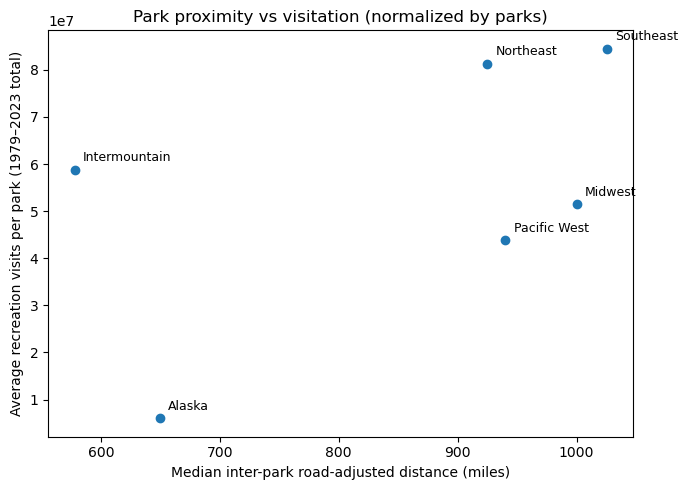

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    region_summary['median_interpark_road_miles'],
    region_summary['avg_visits_per_park']
)

# label each point
for _, r in region_summary.iterrows():
    plt.annotate(
        r['region'],
        (r['median_interpark_road_miles'], r['avg_visits_per_park']),
        textcoords="offset points",
        xytext=(6,6),
        fontsize=9
    )

plt.xlabel("Median inter-park road-adjusted distance (miles)")
plt.ylabel("Average recreation visits per park (1979–2023 total)")
plt.title("Park proximity vs visitation (normalized by parks)")
plt.tight_layout()
plt.show()


## Networks - draw an edge if two parks are within 500 road miles, graphing out the proximity

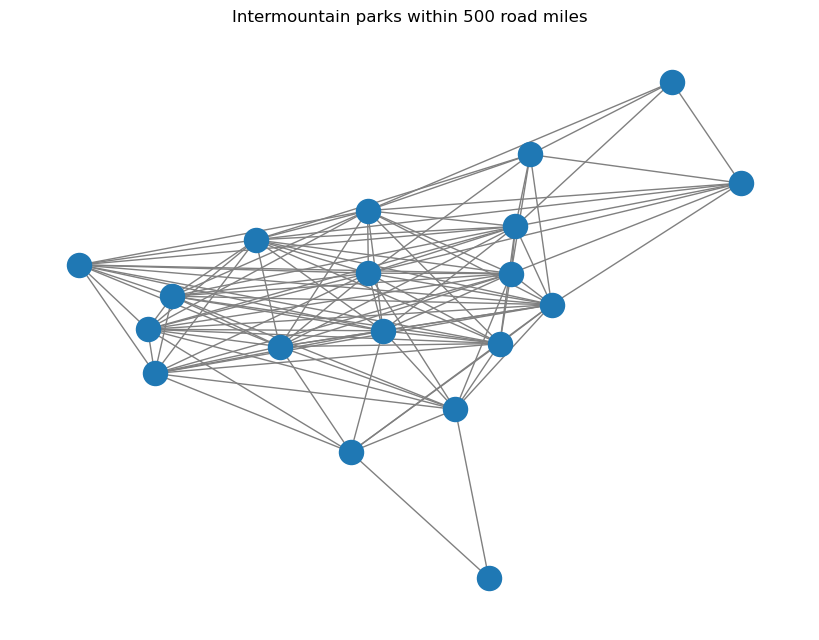

In [40]:
# network for one region
# Draw an edge if two parks are within 500 road miles
import networkx as nx
import matplotlib.pyplot as plt

# choose region and distance threshold
region = "Intermountain"
threshold = 500  # miles

# subset distances
region_edges = dist_clean[
    (dist_clean['region'] == region) &
    (dist_clean['distance_miles'] > 0) &
    (dist_clean['distance_miles'] <= threshold)
]

# build graph
G = nx.Graph()

# add edges
for _, row in region_edges.iterrows():
    G.add_edge(row['from_park'], row['to_park'])

# draw
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)  # layout emphasizes clustering
nx.draw(
    G, pos,
    node_size=300,
    with_labels=False,
    edge_color='gray'
)

plt.title(f"{region} parks within {threshold} road miles")
plt.show()


## Apply this network graphing to all regions

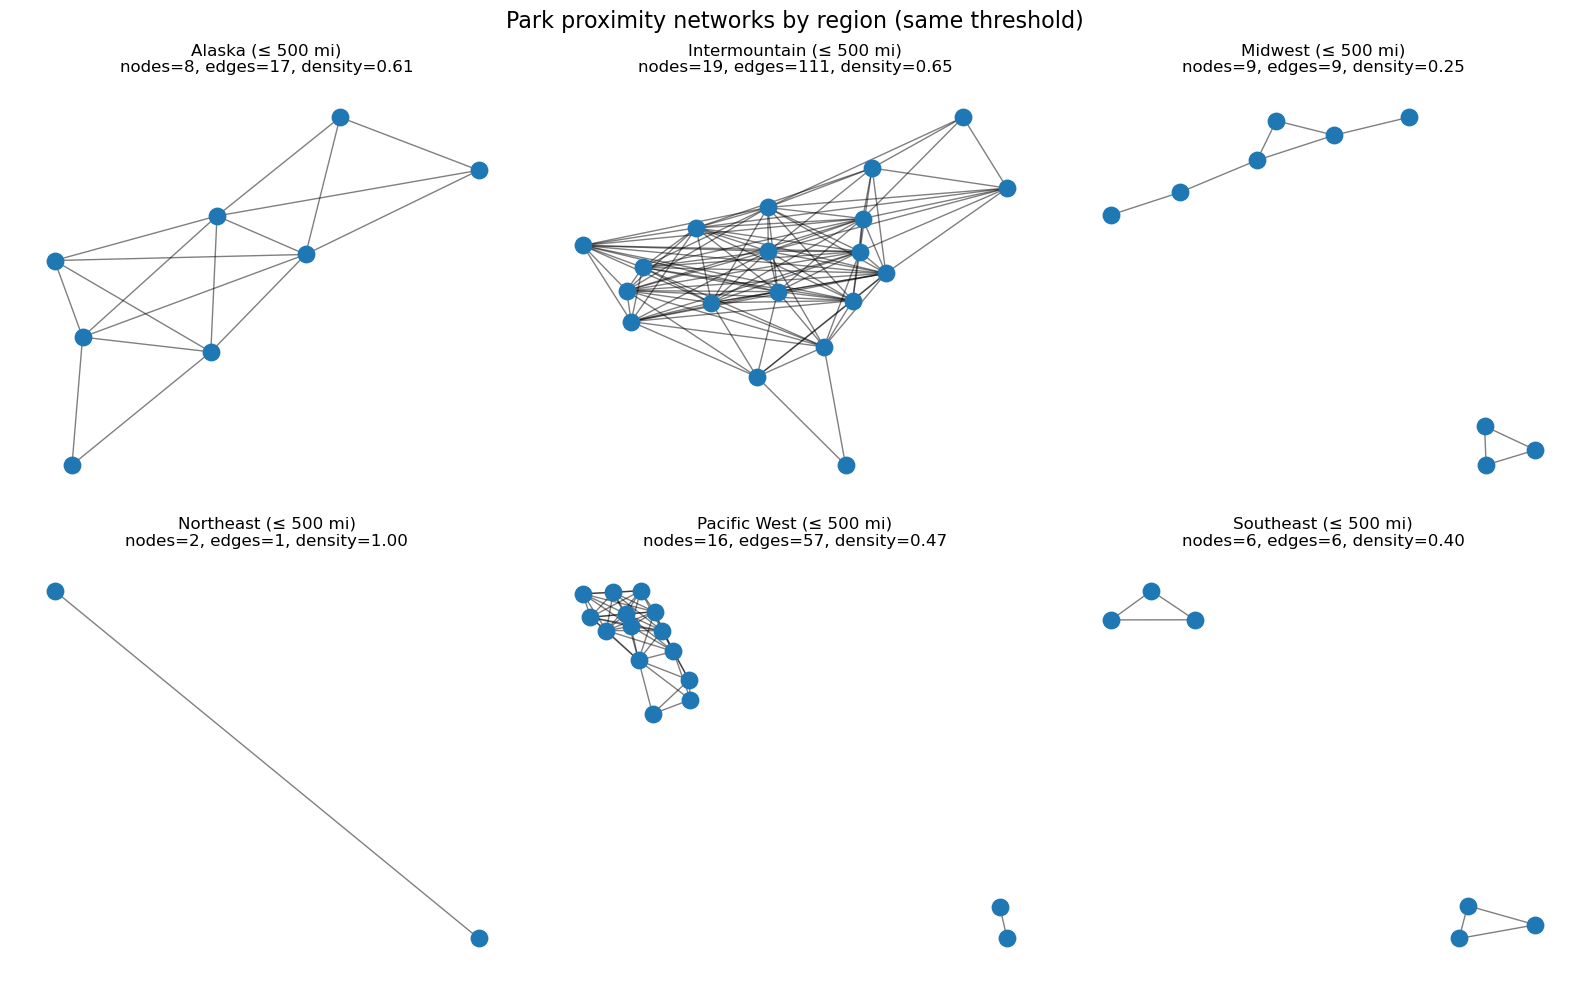

In [41]:
import networkx as nx
import matplotlib.pyplot as plt

threshold = 500  # same rule for all regions

regions = sorted(dist_clean['region'].unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, region in zip(axes, regions):
    # subset edges within threshold
    region_edges = dist_clean[
        (dist_clean['region'] == region) &
        (dist_clean['distance_miles'] > 0) &
        (dist_clean['distance_miles'] <= threshold)
    ]

    # build graph
    G = nx.Graph()
    for _, row in region_edges.iterrows():
        G.add_edge(row['from_park'], row['to_park'])

    # compute a comparable layout per region
    pos = nx.spring_layout(G, seed=42)

    # draw
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=140)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5, width=1)
    ax.set_title(f"{region} (≤ {threshold} mi)\n"
                 f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, density={nx.density(G):.2f}")
    ax.axis('off')

plt.suptitle("Park proximity networks by region (same threshold)", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


### Future idea - adding weights to the edges (to better visualize the distances between parks and having the edges change correspondingly; capping the distance at 500 miles total)

## Adding network density measurement to our region summary

In [42]:
#Add “network density” into your region_summary

import networkx as nx
import pandas as pd

threshold = 500

def compute_density_for_region(region):
    edges = dist_clean[
        (dist_clean['region'] == region) &
        (dist_clean['distance_miles'] > 0) &
        (dist_clean['distance_miles'] <= threshold)
    ]
    G = nx.Graph()
    for _, r in edges.iterrows():
        G.add_edge(r['from_park'], r['to_park'])
    return pd.Series({
        'network_density_500': nx.density(G),
        'edges_500': G.number_of_edges(),
        'nodes_500': G.number_of_nodes()
    })

density_df = (
    pd.DataFrame([compute_density_for_region(r) for r in region_summary['region']])
    .assign(region=region_summary['region'].values)
)

region_summary2 = region_summary.merge(density_df, on='region', how='left')
region_summary2


,region,avg_interpark_road_miles,median_interpark_road_miles,n_pairs,total_visits,n_parks,avg_visits_per_park,network_density_500,edges_500,nodes_500
0,Alaska,627.458897,649.480598,28,48189933,8,6.023742e+06,0.607143,17.0,8.0
1,Intermountain,634.390994,577.978245,171,1117964867,19,5.884026e+07,0.649123,111.0,19.0
2,Midwest,929.758775,999.985921,36,462819570,9,5.142440e+07,0.250000,9.0,9.0
3,Northeast,750.387388,924.900170,3,243951367,3,8.131712e+07,1.000000,1.0,2.0
4,Pacific West,1936.122882,940.160945,136,745932335,17,4.387837e+07,0.475000,57.0,16.0
5,Southeast,1081.837114,1025.174201,21,591324837,7,8.447498e+07,0.400000,6.0,6.0


## Plotting the park visitations (avg visits per park in each region) by the distances (median distance between the parks in a region)

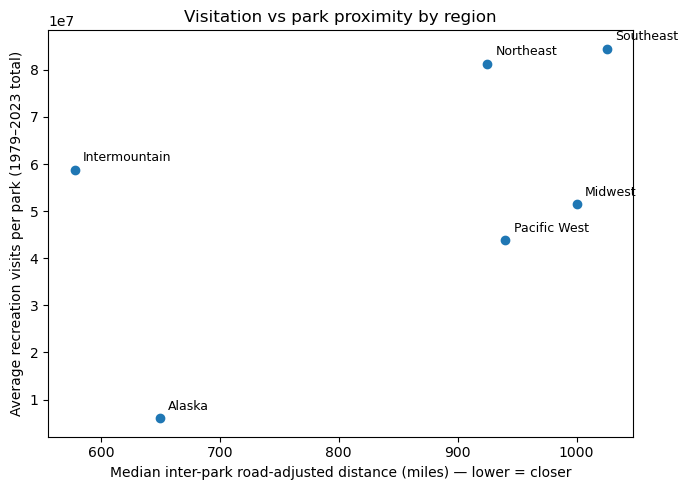

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(region_summary2['median_interpark_road_miles'], region_summary2['avg_visits_per_park'])

for _, r in region_summary2.iterrows():
    plt.annotate(r['region'],
                 (r['median_interpark_road_miles'], r['avg_visits_per_park']),
                 textcoords="offset points", xytext=(6,6), fontsize=9)

plt.xlabel("Median inter-park road-adjusted distance (miles) — lower = closer")
plt.ylabel("Average recreation visits per park (1979–2023 total)")
plt.title("Visitation vs park proximity by region")
plt.tight_layout()
plt.show()


Intermountain: very close and high-ish visitation (supports claim)

Alaska: relatively close but extremely low visitation (contradicts claim)

Northeast & Southeast: far apart but very high visitation (contradicts claim)

Pacific West: far apart and mid-range visitation (ambiguous)

👉 Conclusion:
Proximity alone does not explain visitation across regions. Though the distance between parks can affect how many visits parks in a certain region get, it's not the only thing that can impact it-- for one, population density is a large factor. Areas that have few parks but high population density (such as the Northeast region) may have more visits than regions with parks that are close together but are in fairly "unreachable" areas (such as the Alaskan region, as getting up to Alaska is an arduos task for everyday Americans looking to visit a national park.)

## Graph park visitation against network density (for the specific region)

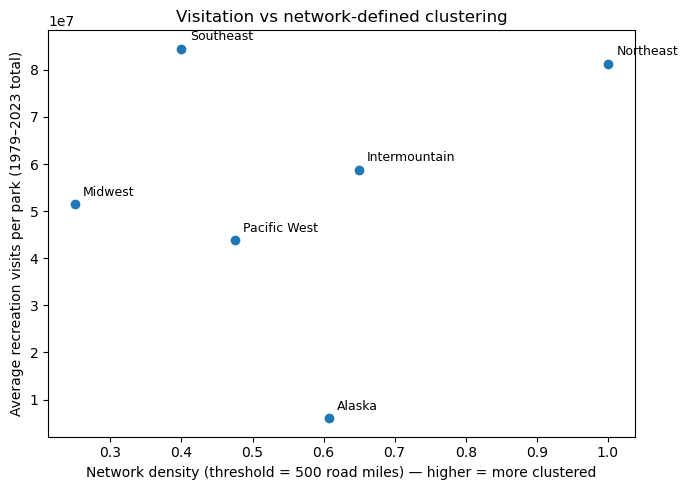

In [44]:
plt.figure(figsize=(7,5))
plt.scatter(region_summary2['network_density_500'], region_summary2['avg_visits_per_park'])

for _, r in region_summary2.iterrows():
    plt.annotate(r['region'],
                 (r['network_density_500'], r['avg_visits_per_park']),
                 textcoords="offset points", xytext=(6,6), fontsize=9)

plt.xlabel("Network density (threshold = 500 road miles) — higher = more clustered")
plt.ylabel("Average recreation visits per park (1979–2023 total)")
plt.title("Visitation vs network-defined clustering")
plt.tight_layout()
plt.show()


If our original claim were strictly true:
Higher density → higher visits
Clear upward trend

What we see instead:
Northeast: highest density and very high visits (supports)
Southeast: moderate density, very high visits (partial support)
Intermountain: high density, moderate-high visits (supports)
Midwest: low density, moderate visits (mixed)
Alaska: high-ish density, very low visits (strong contradiction)


👉 Conclusion:
Clustering is neither necessary nor sufficient for high visitation-- similar to our previous visualization, while the intra-region proximity of parks may play a factor in determining how many people visit the parks, it's not the only factor at play. The accessibiltiy of the parks, the weather (harder to visit further-away parks if it's in bad weather, perhaps), the population density of the region the parks are in, and the ability for people to access the parks themselves (ex. needing to fly or drive a long, long time for the Alaskan region parks), as mentioned above, are playing larger roles than we had originally assumed here.

## Bar charts - rankings of the parks based on proximity & normalized visitation

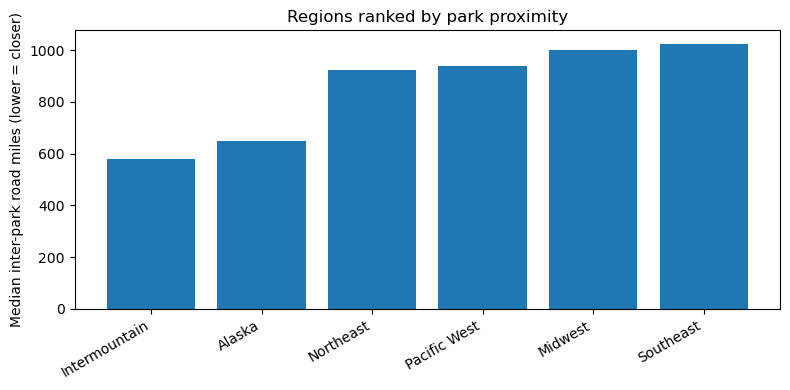

In [70]:
tmp = region_summary2.sort_values('median_interpark_road_miles')

plt.figure(figsize=(8,4))
plt.bar(tmp['region'], tmp['median_interpark_road_miles'])
plt.xticks(rotation=30, ha='right')
plt.ylabel("Median inter-park road miles (lower = closer)")
plt.title("Regions ranked by park proximity")
plt.tight_layout()
plt.show()


Here, again, this falls in line with a trend that we've seen-- the most visited parks are not the most clustered. Again, Alaska is a prime example-- it's a highly-clustered park but it has a low visitation rate. Spatial clustering of parks explains *some* of the reasons behind visitation rates, but not all!

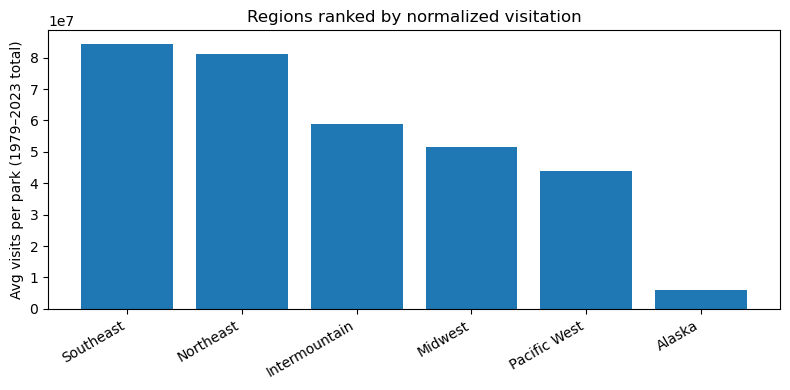

In [69]:
tmp = region_summary2.sort_values('avg_visits_per_park', ascending=False)

plt.figure(figsize=(8,4))
plt.bar(tmp['region'], tmp['avg_visits_per_park'])
plt.xticks(rotation=30, ha='right')
plt.ylabel("Avg visits per park (1979–2023 total)")
plt.title("Regions ranked by normalized visitation")
plt.tight_layout()
plt.show()


Like above-- our original claim (denser regions have higher visitation rates) holds for the Intermountain region (as it may be relatively easier to visit many parks in this region at one time), even when we normalize visitations/distance across the parks, but that's about it. There are other factors that impact the visitation in a region and how high/low it is-- the ability to get between parks, road infrastructure, the number of parks nearby that you can plan a "road trip" to visit many parks, etc.. This falls in line with our previous findings-- the densest park regions are not always the most attended ones.

## Get the "closeness groups" for each region - based on the mean, median, average, which are the "dense" regions and which are the "sparse" ones?

In [47]:
region_summary2['closeness_group'] = pd.qcut(
    region_summary2['median_interpark_road_miles'],
    q=2,
    labels=['high closeness (dense)', 'low closeness (sparse)']
)

region_summary2.groupby('closeness_group')['avg_visits_per_park'].agg(['mean','median','count'])


/var/folders/k1/d5h2hyxn71d7ty4ycmm7v6k00000gn/T/ipykernel_40972/1024994023.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_summary2.groupby('closeness_group')['avg_visits_per_park'].agg(['mean','median','count'])


,mean,median,count
closeness_group,,,
high closeness (dense),4.872704e+07,5.884026e+07,3
low closeness (sparse),5.992592e+07,5.142440e+07,3


While the denser groups have a lower mean average visit per park and higher median visit per park-- showing that having parks that are closer together within a region doesn't necessarily mean they will have a higher attendance (seen in the lower average visits that the sparser parks)-- since we only have a sample size of "3" (the regions), these findings can't really be generalized out into anything significant. If we did wish to apply these findings further, future work we might do would be to examine this across parks, rather than across regions, to view these trends on a more granular level.

## Find if there's a correlation between median interpark distance and the total number of visits for a region

In [71]:
# claim is that regions with closer parks have more total visitation. 
# to test this, we can compute the correlation between median_interpark_road_miles and total_visits
correlation = region_summary[['median_interpark_road_miles', 'total_visits']].corr()
correlation

,median_interpark_road_miles,total_visits
median_interpark_road_miles,1.000000,-0.179904
total_visits,-0.179904,1.000000


A correlatoin of -.17 suggests a weak negative relationship between park proximity and total visitation, meaning that regions with closer parks tend to have slightly higher total visitation, but the relationship is not strong. This could be due to other factors influencing visitation, such as park size, amenities, accessibility, and regional population density.

